# Predicting Wine Quality from Physicochemical Measurements

---
embed-resources: true
echo: false
---

## Introduction
***
Wine quality is traditionally evaluated by trained sommeliers, who judge a wine based on sensory features such as appearance, aroma, taste, and texture. While this expert evaluation is valuable, it is also subjective, expensive, and time-consuming. For a startup interested in building an AI Sommelier, this creates an opportunity to explore whether measurable chemical properties of wine can be used to predict quality in a more consistent and scalable way.

The purpose of this report is to develop a machine learning model that predicts wine quality using physicochemical characteristics such as acidity, sugar content, sulphates, density, alcohol level, and wine color. The data used in this analysis includes both red and white wines, along with quality scores assigned by at least three sensory assessors through blind tasting. To address this problem, this notebook first explores the structure and patterns of the training data, then applies preprocessing steps for missing values and categorical variables, and finally trains and compares decision tree and random forest regression models. The goal is to identify a model that can accurately predict wine quality and help the startup assess wine quality using objective laboratory measurements rather than relying only on human experts.

## Methods

In [79]:
# Data Manipulation & Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Preprocessing & Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Model Building 
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Tuning & Evaluation
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV

### Data
***

In [80]:
# load data
wine_train = pd.read_parquet(
    "https://lab.cs307.org/wine/data/wine-train.parquet",
)
wine_test = pd.read_parquet(
    "https://lab.cs307.org/wine/data/wine-test.parquet",
)

The original source of the data is the following paper:

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. Decision support systems, 47(4), 547-553. https://doi.org/10.1016/j.dss.2009.05.016
However, the data from this paper has become a standard dataset in the machine learning community, and thus is made available via the [UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/).

- [UCI MLR: Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality)

The original data contains two separate datasets, one for red wine and one for white wine. Here, we have combined the data and added a column for the `color` of the wine. We have made additional modifications to the original data.

<br>

### Data Dictionary
***
Each observation in the train, test, and (hidden) production data contains information about a particular Portuguese “Vinho Verde” wine.

> Vinho verde is a unique product from the Minho (northwest) region of Portugal. Medium in alcohol, is it particularly appreciated due to its freshness (specially in the summer).

Original and complete documentation for this data can be found in the original paper. Additionally, minimal documentation is provided by the UCI MLR.

The variable descriptions listed below are available in the Markdown file variable-descriptions.md for ease of inclusion in reports.

<br>

### Variable Descriptions
***
**`quality`**

- `[int64]` the quality of the wine based on evaluation by a minimum of three sensory assessors (using blind tastes), which graded the wine in a scale that ranges from 0 (very bad) to 10 (excellent)

**`color`**

- `[object]` the (human perceivable) color of the wine, red or white

**`fixed acidity`**

- `[float64]` grams of tartaric acid per cubic decimeter

**`volatile acidity`**

- `[float64]` grams of acetic acid per cubic decimeter

**`citric acid`**

- `[float64]` grams of citric acid per cubic decimeter

**`residual sugar`**

- `[float64]` grams of residual sugar per cubic decimeter

**`chlorides`**

- `[float64]` grams of sodium chloride cubic decimeter

**`free sulfur dioxide`**

- `[float64]` milligrams of free sulfur dioxide per cubic decimeter

**`total sulfur dioxide`**

- `[float64]` milligrams of total sulfur dioxide per cubic decimeter

**`density`**

- `[float64]` the total density of the wine in grams per cubic centimeter

**`pH`**

- `[float64]` the acidity of the wine measured using [pH](https://en.m.wikipedia.org/wiki/PH)

**`sulphates`**

- `[float64]` grams of potassium sulphate cubic decimeter

**`alcohol`**

- `[float64]` percent [alcohol by volume](https://en.m.wikipedia.org/wiki/Alcohol_by_volume)

In [81]:
# summary statistics
wine_train.shape, wine_test.shape

((4157, 13), (1040, 13))

Number of samples: The data have 4157 samples (rows) in the training data.

Number of features: Training data has 12 features excluding the target valriable `quality`.

<bar>

### Exploratory Visualization
***

Correlation heatmap of the numeric variables @fig-correlation-heatmap

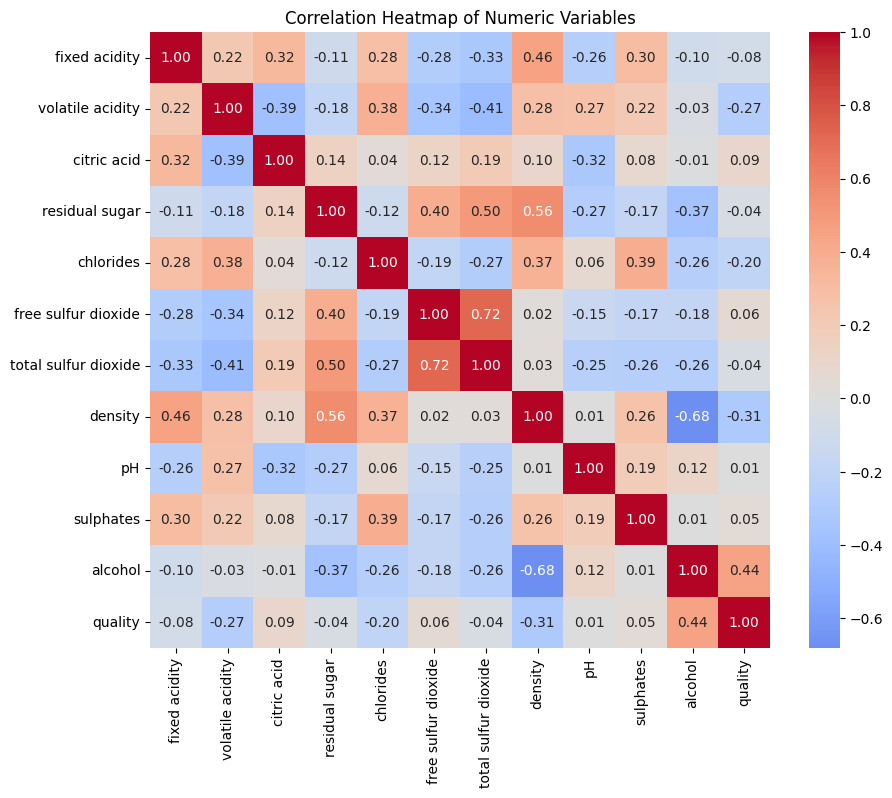

In [82]:
#| label: fig-correlation-heatmap
#| fig-cap: "Correlation heatmap of numeric variables in the training data. The figure summarizes linear relationships among physicochemical measurements and wine quality."

corr = wine_train.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

@fig-quality-distribution Distribution of the target: `quality`

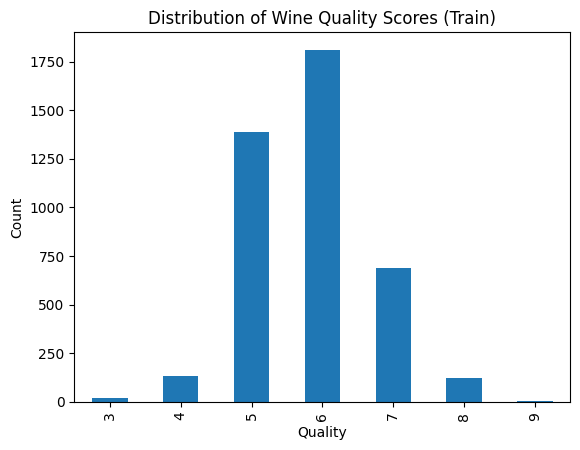

In [83]:
#| label: fig-quality-distribution
#| fig-cap: "Distribution of wine quality scores in the training data. Most wines are rated 5 or 6, while very low and very high quality scores are relatively rare."

wine_train["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Wine Quality Scores (Train)")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

The distribution of wine quality scores in the training data is centered mainly around ratings of 5 and 6, with quality 6 appearing most frequently. Scores at the lower and upper ends of the scale, such as 3, 4, 8, and 9, are much less common. As a result, the models will have more examples to learn from in the middle of the quality range and may perform better for moderate-quality wines than for extreme cases.

***
@fig-color-count Compare quality by wine `color`:

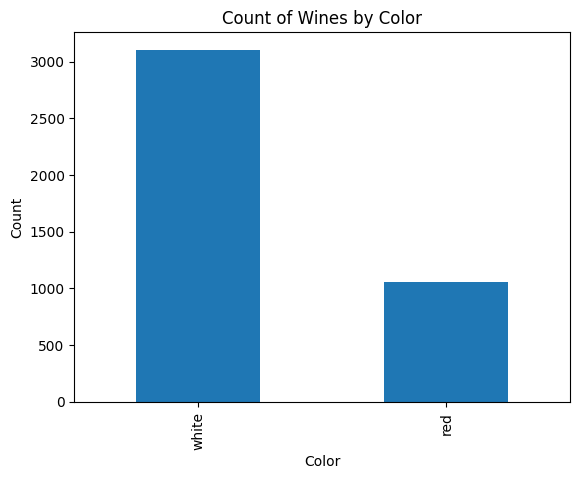

In [84]:
#| label: fig-color-count
#| fig-cap: "Count of red and white wines in the training data. White wines make up the majority of observations."

wine_train["color"].value_counts().plot(kind="bar")
plt.title("Count of Wines by Color")
plt.xlabel("Color")
plt.ylabel("Count")
plt.show()

The training dataset contains substantially more white wines than red wines. This shows that the data is imbalanced across the `color` variable, with white wine observations making up the majority of the sample. As a result, the model will learn from many more examples of white wine than red wine, which may lead to stronger predictive performance for white wines.

***
@fig-missing-values Missing-value check:

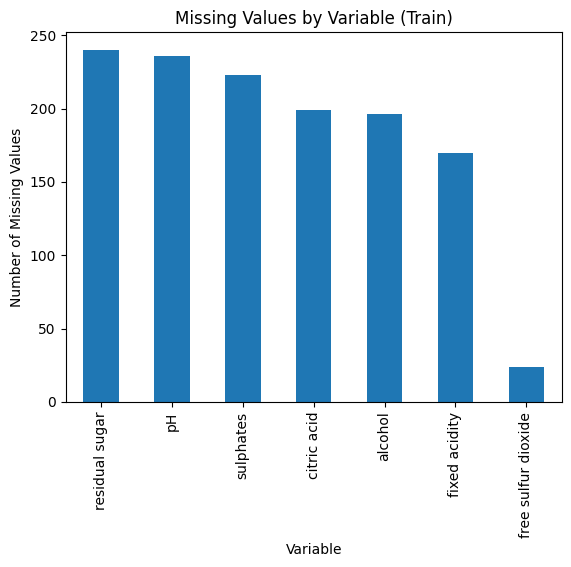

In [85]:
#| label: fig-missing-values
#| fig-cap: "Number of missing values by variable in the training data. Residual sugar, pH, and sulphates have the largest amount of missing data."

missing_counts = wine_train.isna().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

missing_counts.plot(kind="bar")
plt.title("Missing Values by Variable (Train)")
plt.xlabel("Variable")
plt.ylabel("Number of Missing Values")
plt.show()

Several predictor variables in the training data contain a noticeable amount of missing data, while free sulfur dioxide has relatively few missing values. Since these variables may still contain important information for predicting wine quality, using missing value imputation is more appropriate than removing large numbers of observations to ensure data integrity.

### Models

***

To predict wine quality from physicochemical measurements, two tree-based regression models were developed and compared: a decision tree regressor and a random forest regressor.

In [86]:
# create features and target

# create X and y for train
X_train = wine_train.drop("quality", axis=1)
y_train = wine_train["quality"]

# create X and y for test
X_test = wine_test.drop("quality", axis=1)
y_test = wine_test["quality"]

In [87]:
cat_cols = ["color"]
num_cols = [c for c in X_train.columns if c not in cat_cols]
num_cols

['fixed acidity',
 'volatile acidity',
 'citric acid',
 'residual sugar',
 'chlorides',
 'free sulfur dioxide',
 'total sulfur dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol']

#### Descison Tree Model

***

The first model considered was a decision tree regressor. Since the dataset contained both numeric and categorical variables, preprocessing was applied within a modeling pipeline. Missing values in numeric predictors were replaced using the median of each variable, while missing values in the categorical variable `color` were filled using the most frequent category. The `color` variable was then converted into indicator variables using one-hot encoding so that it could be used by the machine learning models.

In [88]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ]
)

In [89]:
DT_pipe = Pipeline([
    ("prep", preprocess),
    ("reg", DecisionTreeRegressor(random_state=0)),
])

In [90]:
DT_param_grid = {
    "reg__max_depth": [4, 5, 6, 7, 8, 10, None],
    "reg__min_samples_leaf": [1, 2, 5, 10, 20],
    "reg__min_samples_split": [2, 5, 10, 20, 50],
    "reg__ccp_alpha": [0.0, 0.0005, 0.001, 0.002, 0.005, 0.01],
}
DT_grid = GridSearchCV(
    DT_pipe,
    param_grid=DT_param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
)

In [ ]:
DT_grid.fit(X_train, y_train)

In [ ]:
print("Best DT CV MAE:", -DT_grid.best_score_)
print("Best DT Params:", DT_grid.best_params_)

Best DT CV MAE: 0.5699001434786635
Best DT Params: {'reg__ccp_alpha': 0.0, 'reg__max_depth': None, 'reg__min_samples_leaf': 1, 'reg__min_samples_split': 2}


#### Random Forest Model

***

After several tries of tuning, the decision tree's cross-validated mean absolute error was still greater than 0.5, so I decided to switch to another model. A Random Forest Regressor was then fitted using the same preprocessing framework. Unlike a single decision tree, a Random Forest combines predictions from many trees, which often improves accuracy and reduces overfitting.

In [ ]:
# Preprocessing

rf_pipe = Pipeline([
    ("prep", preprocess),
    ("reg", RandomForestRegressor(random_state=0, n_jobs=-1))
])

rf_param_grid = {
    "reg__n_estimators": [200],
    "reg__max_depth": [12, 14, 16],
    "reg__min_samples_leaf": [1, 2, 5],
    "reg__max_features": ["sqrt", 0.7],
}

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    scoring="neg_mean_absolute_error",
    cv=3,
    n_jobs=-1,
)

In [ ]:
rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'reg__max_depth': [12, 14, ...], 'reg__max_features': ['sqrt', 0.7], 'reg__min_samples_leaf': [1, 2, ...], 'reg__n_estimators': [200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [ ]:
print("Best RF CV MAE:", -rf_grid.best_score_)
print("Best RF Params:", rf_grid.best_params_)

Best RF CV MAE: 0.49748704296167556
Best RF Params: {'reg__max_depth': 16, 'reg__max_features': 'sqrt', 'reg__min_samples_leaf': 1, 'reg__n_estimators': 200}


The random forest model achieved a best cross-validated mean absolute error of approximately 0.497, which is lower than the decision tree model's CV MAE of 0.570. This indicates that the random forest provided more accurate predictions during model tuning and was better able to capture patterns in the training data.

In [ ]:
best_model = rf_grid.best_estimator_
pred = best_model.predict(X_test)
test_mae = mean_absolute_error(y_test, pred)
print("Final Test MAE:", test_mae)

Final Test MAE: 0.4846423740242555


When evaluated on the separate test set, the final random forest model achieved a test MAE of approximately 0.485, meaning that its predictions were off by less than half a quality point on average. Because the test MAE is slightly lower than the cross-validated MAE, the model appears to generalize well to unseen data rather than showing clear evidence of overfitting. Overall, these results suggest that the random forest model is a strong choice for predicting wine quality and performs better than the single decision tree model for this task.

In [ ]:
# For Modeling Accuracy Check
from joblib import dump
dump(best_model, "wine.joblib", compress=9)

['wine.joblib']

## Results

***

In [ ]:
# report model metrics
print("Best model Test MAE:", test_mae)
print("Best model Params:", rf_grid.best_params_)

Best model Test MAE: 0.4846423740242555
Best model Params: {'reg__max_depth': 16, 'reg__max_features': 'sqrt', 'reg__min_samples_leaf': 1, 'reg__n_estimators': 200}


The decision tree and random forest models were compared using mean absolute error (MAE). Based on cross-validation, the random forest model performed better than the decision tree model. The decision tree achieved a cross-validated MAE of approximately 0.570, while the random forest achieved a lower cross-validated MAE of approximately 0.497. Since lower MAE indicates better predictive accuracy, the random forest was selected as the final model.

The chosen random forest model was then evaluated on the separate test dataset. Its test MAE was approximately 0.485, meaning that the model's predictions differed from the true wine quality scores by about 0.49 points on average. Given that wine quality is measured on a 0 to 10 scale, this level of error suggests that the model provides reasonably accurate predictions using only physicochemical measurements. The test performance was also slightly better than the cross-validation result, which suggests that the model generalized well to unseen data.

### Actual vs. Predicted scatter plot for the test set

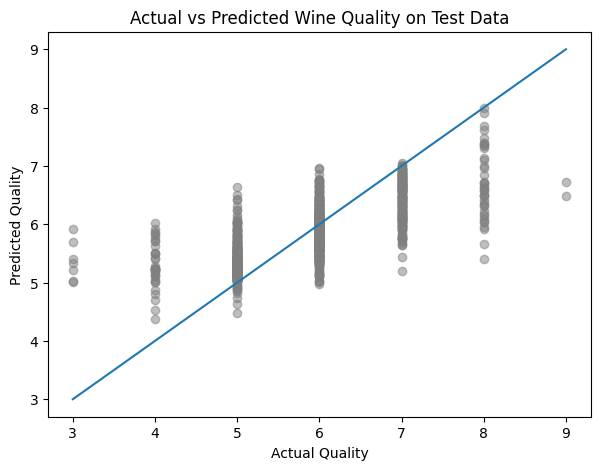

In [ ]:
#| label: fig-actual-predicted-test
#| fig-cap: "Actual versus predicted wine quality scores on the test set. The model captures the overall upward trend in quality, but predictions are pulled toward the center of the rating scale."

plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred, alpha=0.5, c="tab:gray")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="-")
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality on Test Data")
plt.show()

The actual-versus-predicted plot @fig-actual-predicted-test shows that most predictions fall reasonably close to the 45-degree reference line, indicating that the random forest model captures the overall pattern in wine quality fairly well. However, the predictions are more concentrated around the middle of the quality range, which suggests that the model performs best for average-quality wines and is less precise for rare low or high quality scores. This is consistent with the distribution of the training data, where most wines were rated 5 or 6.

In [ ]:
# serialize model
import joblib

joblib.dump(best_model, "best_model.joblib", compress=9)
print("Saved model to best_model.joblib")

Saved model to best_model.joblib


## Discussion
***
Based on the results of this analysis, I would **not** recommend using the model as a full replacement for human sommeliers, but I would recommend using it as a decision-support tool in the startup’s AI Sommelier system. The final random forest model performed reasonably well, with a test MAE of about 0.485, which means its predictions were off by less than half a quality point on average. This shows that physicochemical measurements contain useful information about perceived wine quality and that the model can provide consistent, data-driven estimates.

### Benefits
***
The main benefit of this model is that it provides a faster, cheaper, and more consistent way to estimate wine quality. For the startup, this could help screen wines efficiently and support quality assessment before expert review. It may also reduce the cost and time required for relying only on trained human evaluators.

### Limitations
***
the quality scores in the data are concentrated mostly in the middle range, especially around 5 and 6, while very low and very high scores are rare. As a result, the model performs best for average wines and is less reliable for extreme cases. This is also visible in the prediction patterns, where low-quality wines tend to be predicted too high and high-quality wines tend to be predicted too low.

Because of these limitations, the model would be most useful as a decision-support system rather than a final decision-maker. It could help the startup identify wines that may deserve closer expert attention, but final judgments should still involve human evaluation.

### Future Improvements
***
Before broader real-world use, the model could be improved by using a larger and more balanced dataset, especially with more examples of rare quality scores. Adding more relevant features and testing the model on new wines from different sources would also help confirm that it performs reliably in practice.